
# 02. Baseline-модели: L1 Logistic Regression и CatBoost

## Цель ноутбука

На предыдущем этапе мы выполнили EDA и увидели, что:

- в исходном датасете 840 пациентов и 48 столбцов;
- 10 столбцов являются целевыми переменными, `patient_id` — идентификатором;
- остаётся 37 допустимых входных признаков;
- часть лабораторных показателей сильно коррелирует;
- редкие лабораторные исследования имеют большое количество пропусков;
- сама структура пропусков может содержать информацию о классе;
- L1 в предыдущем ноутбуке была недостаточно разреженной, поэтому не дала полезного отбора признаков.

В этом ноутбуке мы строим **честные baseline-модели** для прямой классификации `anemia_class` на 12 классов:

1. L1 Logistic Regression на всех допустимых признаках.
2. L1 Logistic Regression с компактным набором признаков.
3. CatBoost на всех допустимых признаках.
4. CatBoost с компактным набором признаков.

Главный принцип:

> **outer validation никогда не участвует в preprocessing, feature selection или подборе гиперпараметров.**

Финальные метрики считаются только по out-of-fold предсказаниям.

---

## Почему пока не увеличиваем датасет

В первом EDA уже было установлено, что условно здоровых пациентов около 13%, то есть их доля соответствует ориентиру 10–20%.

Сейчас не добавляем synthetic data, SMOTE или внешние источники, потому что сначала нужен честный baseline на исходных 840 пациентах.

После этого можно будет сравнить:

\[
baseline \rightarrow baseline + external\ data
\]

и объективно оценить эффект расширения выборки.


In [1]:

import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from scipy.stats import kruskal
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import (
    f1_score,
    balanced_accuracy_score,
    accuracy_score,
    log_loss,
    ConfusionMatrixDisplay,
    classification_report,
)

try:
    from catboost import CatBoostClassifier
except ImportError as exc:
    raise ImportError(
        "Не установлен catboost. Установи его в окружение meditron: "
        "`pip install catboost` или `conda install -c conda-forge catboost`."
    ) from exc

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
N_SPLITS = 5

print("Импорты выполнены успешно.")


Импорты выполнены успешно.



## 1. Загрузка данных

Ноутбук ищет CSV в нескольких стандартных местах проекта.  
Это позволяет запускать его как из корня репозитория, так и из папки `notebooks`.


In [2]:

def find_dataset():
    candidates = [
        Path("data/raw/deficiency_anemia.csv"),
        Path("../data/raw/deficiency_anemia.csv"),
        Path("deficiency_anemia.csv"),
        Path("data/raw/(СУ)deficiency_anemia (2).csv"),
        Path("../data/raw/(СУ)deficiency_anemia (2).csv"),
        Path("(СУ)deficiency_anemia (2).csv"),
    ]

    for path in candidates:
        if path.exists():
            return path.resolve()

    search_roots = [Path.cwd(), Path.cwd().parent]
    matches = []
    for root in search_roots:
        matches.extend(root.glob("**/*deficiency_anemia*.csv"))

    matches = [p for p in matches if p.is_file()]
    if matches:
        return matches[0].resolve()

    raise FileNotFoundError(
        "Не найден CSV с deficiency_anemia. "
        "Проверь, что файл лежит в data/raw."
    )


DATA_PATH = find_dataset()
df = pd.read_csv(DATA_PATH)

print("Файл:", DATA_PATH)
print("Размер:", df.shape)
display(df.head())


Файл: /home/sinopah/meditron/data/raw/deficiency_anemia.csv
Размер: (840, 48)


,patient_id,age_years,sex,hemoglobin,RBC,hematocrit,MCV,MCH,MCHC,RDW,...,anemia,iron_deficiency,B12_deficiency,folate_deficiency,B6_deficiency,copper_deficiency,inflammation_anemia,mixed_deficiency,anemia_class,deficiency_cause
0,P000001,64,M,139.6,4.99,41.8,83.3,28.0,332.5,13.3,...,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
1,P000002,52,F,122.3,3.87,35.5,90.0,31.6,343.7,19.8,...,0,0,0,1,0,0,0,0,folate_deficiency_no_anemia,folate_deficiency
2,P000003,43,F,144.9,5.20,44.6,86.1,27.9,329.2,14.7,...,0,1,0,0,0,0,0,0,latent_deficiency,iron_deficiency
3,P000004,26,F,121.7,4.46,39.0,86.9,27.3,316.2,16.7,...,0,0,1,0,0,0,0,0,B12_deficiency_no_anemia,B12_deficiency
4,P000005,30,F,111.5,2.98,32.5,109.1,37.5,341.6,19.7,...,1,0,1,0,0,0,0,0,B12_deficiency_anemia,B12_deficiency



## 2. Фиксируем разрешённые входы и target

Как и в EDA, не допускаем target leakage.

Нельзя подавать модели:

- `patient_id`;
- бинарные целевые признаки дефицитов;
- `anemia_class`;
- `deficiency_cause`.

`anemia_class` — целевая переменная этого baseline.


In [3]:

ID_COLUMN = "patient_id"

BINARY_TARGETS = [
    "anemia",
    "iron_deficiency",
    "B12_deficiency",
    "folate_deficiency",
    "B6_deficiency",
    "copper_deficiency",
    "inflammation_anemia",
    "mixed_deficiency",
]

TARGET_COLUMNS = BINARY_TARGETS + [
    "anemia_class",
    "deficiency_cause",
]

FEATURE_COLUMNS = [
    c for c in df.columns
    if c not in TARGET_COLUMNS + [ID_COLUMN]
]

assert ID_COLUMN in df.columns
assert "anemia_class" in df.columns
assert len(FEATURE_COLUMNS) == 37
assert not (set(FEATURE_COLUMNS) & set(TARGET_COLUMNS))

X = df[FEATURE_COLUMNS].copy()
y = df["anemia_class"].copy()

CLASSES = np.array(sorted(y.unique()))

print("Количество пациентов:", len(df))
print("Количество разрешённых признаков:", len(FEATURE_COLUMNS))
print("Количество классов:", len(CLASSES))
print()
display(y.value_counts().rename("n").to_frame())


Количество пациентов: 840
Количество разрешённых признаков: 37
Количество классов: 12



,n
anemia_class,
iron_deficiency_anemia,115
mixed_deficiency,115
no_anemia_no_deficiency,110
latent_deficiency,85
anemia_other,75
B12_deficiency_anemia,65
inflammation_anemia,65
B12_deficiency_no_anemia,50
folate_deficiency_anemia,50



## 3. Почему используем nested validation

Для каждого outer fold:

```text
outer train
    │
    ├── feature selection (только для compact-модели)
    │
    ├── preprocessing
    │
    └── inner CV для подбора C у L1
             │
             ▼
        готовая модель
             │
             ▼
outer validation
```

Таким образом пациент из outer validation не влияет:

- на медианы для заполнения пропусков;
- на StandardScaler;
- на OneHotEncoder;
- на выбор признаков;
- на выбор коэффициента регуляризации `C`.

Это и есть оценка без selection leakage.



## 4. Функции для train-only feature selection

Compact feature set строится **заново внутри каждого outer fold**.

Логика:

1. Для числовых признаков считаем Kruskal–Wallis только на `outer train`.
2. Считаем effect size `epsilon²`.
3. Строим Spearman-корреляции только на `outer train`.
4. При `|rho| >= 0.75` близкие признаки объединяются иерархической кластеризацией.
5. В каждом корреляционном кластере выбирается наиболее сильный представитель.
6. Ранжирование учитывает и эффект, и доступность признака:

\[
score = \epsilon^2 \cdot (0.5 + 0.5 \cdot coverage)
\]

Так редкий, но сильный показатель не исчезает автоматически, однако очень высокий процент пропусков снижает его приоритет.

Категориальные признаки (здесь прежде всего `sex`) сохраняются отдельно.

`MAX_NUMERIC_FEATURES = 18` — рабочий размер compact baseline.  
Мы не утверждаем, что 18 — медицински оптимальное число: это эксперимент, который сравнивается с моделью на всех 37 признаках.


In [4]:

def kruskal_effect_table(data, features, target_col):
    rows = []

    for feature in features:
        groups = [
            group[feature].dropna().to_numpy()
            for _, group in data.groupby(target_col)
            if group[feature].notna().sum() >= 2
        ]

        if len(groups) < 2:
            continue

        h_stat, p_value = kruskal(*groups)
        n = sum(len(g) for g in groups)
        k = len(groups)

        epsilon2 = (
            max(0.0, (h_stat - k + 1) / (n - k))
            if n > k else 0.0
        )

        missing_fraction = data[feature].isna().mean()
        coverage = 1.0 - missing_fraction

        selection_score = epsilon2 * (0.5 + 0.5 * coverage)

        rows.append({
            "feature": feature,
            "epsilon2": epsilon2,
            "p_value": p_value,
            "missing_fraction": missing_fraction,
            "coverage": coverage,
            "selection_score": selection_score,
        })

    return (
        pd.DataFrame(rows)
        .sort_values("selection_score", ascending=False)
        .reset_index(drop=True)
    )


def select_compact_features(
    train_df,
    feature_columns,
    target_col="anemia_class",
    corr_threshold=0.75,
    max_numeric_features=18,
):
    numeric_features = (
        train_df[feature_columns]
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categorical_features = [
        c for c in feature_columns
        if c not in numeric_features
    ]

    evidence = kruskal_effect_table(
        train_df,
        numeric_features,
        target_col,
    )

    if len(numeric_features) == 1:
        evidence["cluster"] = 1
    else:
        corr = (
            train_df[numeric_features]
            .corr(method="spearman", min_periods=20)
            .abs()
            .fillna(0.0)
            .copy()
        )

        for i in range(len(corr)):
            corr.iat[i, i] = 1.0

        distance = (1.0 - corr).clip(0.0, 1.0)
        distance = (distance + distance.T) / 2

        for i in range(len(distance)):
            distance.iat[i, i] = 0.0

        condensed = squareform(
            distance.to_numpy(copy=True),
            checks=True,
        )

        linkage_matrix = linkage(
            condensed,
            method="average",
        )

        cluster_labels = fcluster(
            linkage_matrix,
            t=1.0 - corr_threshold,
            criterion="distance",
        )

        cluster_map = pd.DataFrame({
            "feature": numeric_features,
            "cluster": cluster_labels,
        })

        evidence = evidence.merge(
            cluster_map,
            on="feature",
            how="left",
        )

    representatives = (
        evidence
        .sort_values(
            ["cluster", "selection_score", "missing_fraction"],
            ascending=[True, False, True],
        )
        .groupby("cluster", as_index=False)
        .first()
        .sort_values("selection_score", ascending=False)
    )

    selected_numeric = (
        representatives
        .head(max_numeric_features)["feature"]
        .tolist()
    )

    selected = categorical_features + selected_numeric

    return selected, evidence, representatives


demo_selected, demo_evidence, demo_representatives = select_compact_features(
    df,
    FEATURE_COLUMNS,
)

print("Пример compact-набора на всём датасете — только для просмотра, НЕ для оценки:")
print("Количество:", len(demo_selected))
print(demo_selected)

display(
    demo_representatives.head(20)[
        ["feature", "cluster", "epsilon2", "missing_fraction", "selection_score"]
    ].round(3)
)


Пример compact-набора на всём датасете — только для просмотра, НЕ для оценки:
Количество: 19
['sex', 'hemoglobin', 'ferritin', 'TSAT', 'RDW', 'UIBC', 'MCV', 'homocysteine', 'Ret_He', 'sTfR', 'transferrin', 'MMA', 'vitamin_B12', 'copper', 'folate', 'LDH', 'haptoglobin', 'vitamin_B6', 'CRP']


,feature,cluster,epsilon2,missing_fraction,selection_score
10,hemoglobin,11,0.685,0.000,0.685
16,ferritin,17,0.684,0.293,0.584
20,TSAT,21,0.681,0.357,0.559
11,RDW,12,0.563,0.018,0.558
15,UIBC,16,0.658,0.357,0.541
21,MCV,22,0.538,0.000,0.538
8,homocysteine,9,0.754,0.645,0.511
18,Ret_He,19,0.676,0.731,0.429
17,sTfR,18,0.622,0.700,0.404
19,transferrin,20,0.479,0.357,0.393



> **Важно:** список выше показан только для интерпретации.  
> Он **не используется как заранее зафиксированный набор для OOF-оценки**, потому что был рассчитан на всех 840 пациентах.

В реальном validation каждый fold получит собственный список `selected_features`, рассчитанный только по training-части.



## 5. Preprocessing для L1

Для Logistic Regression:

- числовые признаки → median imputation + StandardScaler;
- категориальные → most-frequent imputation + OneHotEncoder;
- затем L1 Logistic Regression.

В первом ноутбуке диапазон `C` оказался слишком мягким, и почти все коэффициенты оставались ненулевыми.

Теперь используем более сильную регуляризацию:

```python
C_GRID = 10 ** [-4, ..., 0]
```

Меньше `C` → сильнее L1-регуляризация → больше коэффициентов становятся нулевыми.


In [5]:

C_GRID = np.logspace(-4, 0, 9)

def make_l1_pipeline(feature_names):
    numeric_cols = (
        X[feature_names]
        .select_dtypes(include=np.number)
        .columns
        .tolist()
    )

    categorical_cols = [
        c for c in feature_names
        if c not in numeric_cols
    ]

    preprocessor = ColumnTransformer(
        transformers=[
            (
                "num",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_cols,
            ),
            (
                "cat",
                Pipeline([
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    (
                        "onehot",
                        OneHotEncoder(
                            handle_unknown="ignore",
                            drop="if_binary",
                        ),
                    ),
                ]),
                categorical_cols,
            ),
        ],
        verbose_feature_names_out=False,
    )

    model = LogisticRegression(
        penalty="l1",
        solver="saga",
        class_weight="balanced",
        max_iter=7000,
        random_state=RANDOM_STATE,
    )

    return Pipeline([
        ("preprocessor", preprocessor),
        ("model", model),
    ])


## 6. Вспомогательные функции для честной OOF-оценки

In [6]:

def align_probabilities(probabilities, model_classes, global_classes):
    aligned = np.zeros(
        (probabilities.shape[0], len(global_classes)),
        dtype=float,
    )

    class_to_position = {
        cls: i for i, cls in enumerate(global_classes)
    }

    for model_position, cls in enumerate(model_classes):
        aligned[:, class_to_position[cls]] = probabilities[:, model_position]

    return aligned


def multiclass_brier_score(y_true, probabilities, classes):
    class_to_position = {
        cls: i for i, cls in enumerate(classes)
    }

    y_onehot = np.zeros_like(probabilities)
    for row, label in enumerate(y_true):
        y_onehot[row, class_to_position[label]] = 1.0

    return np.mean(
        np.sum((probabilities - y_onehot) ** 2, axis=1)
    )


def calculate_fold_metrics(y_true, pred, prob, classes):
    return {
        "macro_f1": f1_score(
            y_true,
            pred,
            average="macro",
            zero_division=0,
        ),
        "balanced_accuracy": balanced_accuracy_score(
            y_true,
            pred,
        ),
        "accuracy": accuracy_score(
            y_true,
            pred,
        ),
        "log_loss": log_loss(
            y_true,
            prob,
            labels=classes,
        ),
        "brier": multiclass_brier_score(
            np.asarray(y_true),
            prob,
            classes,
        ),
    }


def prepare_catboost_frame(frame):
    result = frame.copy()
    categorical = (
        result
        .select_dtypes(exclude=np.number)
        .columns
        .tolist()
    )

    for col in categorical:
        result[col] = (
            result[col]
            .fillna("__MISSING__")
            .astype(str)
        )

    return result, categorical



## 7. Outer CV

Используем один и тот же `StratifiedKFold` для всех четырёх моделей.

Так сравнение выполняется на **одинаковых пациентах в одинаковых folds**.

Модели:

- `L1_full`
- `L1_compact`
- `CatBoost_full`
- `CatBoost_compact`

Для compact-моделей feature selection запускается только на outer train.


In [7]:

outer_cv = StratifiedKFold(
    n_splits=N_SPLITS,
    shuffle=True,
    random_state=RANDOM_STATE,
)

MODEL_NAMES = [
    "L1_full",
    "L1_compact",
    "CatBoost_full",
    "CatBoost_compact",
]

oof_probabilities = {
    name: np.zeros((len(df), len(CLASSES)), dtype=float)
    for name in MODEL_NAMES
}

oof_predictions = {
    name: np.empty(len(df), dtype=object)
    for name in MODEL_NAMES
}

fold_metrics = []
compact_selection_rows = []
l1_nonzero_rows = []



## 8. Обучение четырёх baseline-моделей

Этот блок самый тяжёлый по времени.

Для L1 на каждом outer fold выполняется внутренний `GridSearchCV` по `C`.

CatBoost здесь используется как **фиксированный baseline**, без подбора гиперпараметров по outer validation.  
Это специально: если настраивать CatBoost по тому же outer validation, оценка перестанет быть честной.


In [8]:

for fold, (train_idx, valid_idx) in enumerate(
    outer_cv.split(X, y),
    start=1,
):
    print(f"\n========== FOLD {fold}/{N_SPLITS} ==========")

    train_df = df.iloc[train_idx].copy()
    valid_df = df.iloc[valid_idx].copy()

    y_train = train_df["anemia_class"]
    y_valid = valid_df["anemia_class"]

    compact_features, fold_evidence, fold_representatives = (
        select_compact_features(
            train_df,
            FEATURE_COLUMNS,
            target_col="anemia_class",
            corr_threshold=0.75,
            max_numeric_features=18,
        )
    )

    print("Compact features:", len(compact_features))

    for feature in compact_features:
        compact_selection_rows.append({
            "fold": fold,
            "feature": feature,
        })

    feature_sets = {
        "full": FEATURE_COLUMNS,
        "compact": compact_features,
    }

    # L1
    for feature_mode, features in feature_sets.items():
        model_name = f"L1_{feature_mode}"

        pipeline = make_l1_pipeline(features)

        inner_cv = StratifiedKFold(
            n_splits=3,
            shuffle=True,
            random_state=RANDOM_STATE + fold,
        )

        search = GridSearchCV(
            estimator=pipeline,
            param_grid={
                "model__C": C_GRID,
            },
            scoring="f1_macro",
            cv=inner_cv,
            refit=True,
            n_jobs=1,
        )

        search.fit(
            train_df[features],
            y_train,
        )

        pred = search.predict(
            valid_df[features]
        )

        prob = search.predict_proba(
            valid_df[features]
        )

        prob = align_probabilities(
            prob,
            search.classes_,
            CLASSES,
        )

        oof_predictions[model_name][valid_idx] = pred
        oof_probabilities[model_name][valid_idx] = prob

        metrics = calculate_fold_metrics(
            y_valid,
            pred,
            prob,
            CLASSES,
        )

        metrics.update({
            "fold": fold,
            "model": model_name,
            "best_C": search.best_params_["model__C"],
            "n_features_raw": len(features),
        })

        fold_metrics.append(metrics)

        best_pipeline = search.best_estimator_
        transformed_names = (
            best_pipeline
            .named_steps["preprocessor"]
            .get_feature_names_out()
        )

        coef = best_pipeline.named_steps["model"].coef_
        nonzero = (np.abs(coef) > 1e-10).any(axis=0)

        for feature_name, selected in zip(
            transformed_names,
            nonzero,
        ):
            l1_nonzero_rows.append({
                "fold": fold,
                "model": model_name,
                "feature": feature_name,
                "nonzero": int(selected),
                "best_C": search.best_params_["model__C"],
            })

        print(
            f"{model_name}: "
            f"Macro-F1={metrics['macro_f1']:.3f}, "
            f"C={search.best_params_['model__C']:.5f}, "
            f"nonzero={nonzero.sum()}/{len(nonzero)}"
        )

    # CatBoost
    for feature_mode, features in feature_sets.items():
        model_name = f"CatBoost_{feature_mode}"

        X_train_cb, cat_cols = prepare_catboost_frame(
            train_df[features]
        )

        X_valid_cb, _ = prepare_catboost_frame(
            valid_df[features]
        )

        model = CatBoostClassifier(
            iterations=350,
            depth=5,
            learning_rate=0.05,
            l2_leaf_reg=5.0,
            loss_function="MultiClass",
            auto_class_weights="Balanced",
            random_seed=RANDOM_STATE + fold,
            verbose=False,
            allow_writing_files=False,
        )

        model.fit(
            X_train_cb,
            y_train,
            cat_features=cat_cols,
        )

        pred = model.predict(
            X_valid_cb
        ).reshape(-1)

        prob = model.predict_proba(
            X_valid_cb
        )

        prob = align_probabilities(
            prob,
            model.classes_,
            CLASSES,
        )

        oof_predictions[model_name][valid_idx] = pred
        oof_probabilities[model_name][valid_idx] = prob

        metrics = calculate_fold_metrics(
            y_valid,
            pred,
            prob,
            CLASSES,
        )

        metrics.update({
            "fold": fold,
            "model": model_name,
            "best_C": np.nan,
            "n_features_raw": len(features),
        })

        fold_metrics.append(metrics)

        print(
            f"{model_name}: "
            f"Macro-F1={metrics['macro_f1']:.3f}"
        )

print("\nOOF обучение завершено.")



========== FOLD 1/5 ==========
Compact features: 19
L1_full: Macro-F1=0.926, C=0.31623, nonzero=37/37
L1_compact: Macro-F1=0.880, C=1.00000, nonzero=19/19
CatBoost_full: Macro-F1=0.838
CatBoost_compact: Macro-F1=0.871

========== FOLD 2/5 ==========
Compact features: 19
L1_full: Macro-F1=0.836, C=1.00000, nonzero=37/37
L1_compact: Macro-F1=0.775, C=0.31623, nonzero=19/19
CatBoost_full: Macro-F1=0.806
CatBoost_compact: Macro-F1=0.794

========== FOLD 3/5 ==========
Compact features: 19
L1_full: Macro-F1=0.858, C=0.31623, nonzero=37/37
L1_compact: Macro-F1=0.844, C=0.31623, nonzero=19/19
CatBoost_full: Macro-F1=0.832
CatBoost_compact: Macro-F1=0.788

========== FOLD 4/5 ==========
Compact features: 19
L1_full: Macro-F1=0.873, C=1.00000, nonzero=37/37
L1_compact: Macro-F1=0.844, C=1.00000, nonzero=19/19
CatBoost_full: Macro-F1=0.858
CatBoost_compact: Macro-F1=0.814

========== FOLD 5/5 ==========
Compact features: 19
L1_full: Macro-F1=0.829, C=0.31623, nonzero=36/37
L1_compact: Macro-F1=


## 9. Метрики по folds

Смотрим не только среднее, но и разброс.

При маленьком датасете высокая стандартная ошибка между folds — важный сигнал нестабильности.


In [9]:

fold_metrics_df = pd.DataFrame(fold_metrics)

metric_columns = [
    "macro_f1",
    "balanced_accuracy",
    "accuracy",
    "log_loss",
    "brier",
]

fold_summary = (
    fold_metrics_df
    .groupby("model")[metric_columns]
    .agg(["mean", "std"])
)

display(fold_summary.round(4))


macro_f1         balanced_accuracy         accuracy          \
                     mean     std              mean     std     mean     std   
model                                                                          
CatBoost_compact   0.8111  0.0353            0.8145  0.0367   0.8345  0.0236   
CatBoost_full      0.8302  0.0198            0.8312  0.0199   0.8464  0.0148   
L1_compact         0.8311  0.0393            0.8381  0.0374   0.8381  0.0340   
L1_full            0.8645  0.0384            0.8704  0.0374   0.8655  0.0317   

                 log_loss           brier          
                     mean     std    mean     std  
model                                              
CatBoost_compact   0.6320  0.0376  0.2911  0.0197  
CatBoost_full      0.6079  0.0474  0.2791  0.0217  
L1_compact         0.4863  0.0543  0.2372  0.0269  
L1_full            0.4333  0.0433  0.2146  0.0274


## 10. Итоговые OOF-метрики

Здесь каждый пациент предсказан только моделью, которая **не обучалась на этом пациенте**.

Именно эти значения считаем основными baseline-результатами.


In [10]:

oof_summary_rows = []

for model_name in MODEL_NAMES:
    pred = oof_predictions[model_name]
    prob = oof_probabilities[model_name]

    metrics = calculate_fold_metrics(
        y,
        pred,
        prob,
        CLASSES,
    )

    metrics["model"] = model_name
    oof_summary_rows.append(metrics)

oof_summary = (
    pd.DataFrame(oof_summary_rows)
    .set_index("model")
    .sort_values("macro_f1", ascending=False)
)

display(oof_summary.round(4))


,macro_f1,balanced_accuracy,accuracy,log_loss,brier
model,,,,,
L1_full,0.8647,0.8704,0.8655,0.4333,0.2146
L1_compact,0.8310,0.8381,0.8381,0.4863,0.2372
CatBoost_full,0.8303,0.8312,0.8464,0.6079,0.2791
CatBoost_compact,0.8117,0.8145,0.8345,0.6320,0.2911



## 11. Проверяем, стала ли L1 действительно sparse

Это исправляет проблему первого ноутбука.

Для каждого признака считаем, в скольких folds он имел ненулевой коэффициент после inner-CV подбора `C`.


In [11]:

l1_nonzero_df = pd.DataFrame(l1_nonzero_rows)

l1_stability = (
    l1_nonzero_df
    .groupby(["model", "feature"])["nonzero"]
    .agg(["sum", "mean"])
    .rename(columns={
        "sum": "selected_folds",
        "mean": "stability",
    })
    .reset_index()
    .sort_values(
        ["model", "stability"],
        ascending=[True, False],
    )
)

print("Выбранные значения C:")
display(
    fold_metrics_df[
        fold_metrics_df["model"].str.startswith("L1")
    ][["fold", "model", "best_C", "macro_f1"]]
    .round(5)
)

print("\nСтабильность ненулевых коэффициентов:")
display(l1_stability)


Выбранные значения C:


,fold,model,best_C,macro_f1
0,1,L1_full,0.31623,0.92574
1,1,L1_compact,1.00000,0.87967
4,2,L1_full,1.00000,0.83616
5,2,L1_compact,0.31623,0.77475
8,3,L1_full,0.31623,0.85836
9,3,L1_compact,0.31623,0.84358
12,4,L1_full,1.00000,0.87290
13,4,L1_compact,1.00000,0.84448
16,5,L1_full,0.31623,0.82934
17,5,L1_compact,1.00000,0.81315



Стабильность ненулевых коэффициентов:


,model,feature,selected_folds,stability
0,L1_compact,CRP,3,1.0
1,L1_compact,LDH,5,1.0
2,L1_compact,MCH,3,1.0
3,L1_compact,MCHC,1,1.0
4,L1_compact,MCV,2,1.0
5,L1_compact,MMA,3,1.0
6,L1_compact,RDW,5,1.0
7,L1_compact,Ret_He,5,1.0
8,L1_compact,TSAT,5,1.0
9,L1_compact,UIBC,5,1.0



## 12. Стабильность compact feature selection

Так как feature selection выполнялся независимо внутри каждого outer fold, можно посмотреть:

> какие признаки стабильно выбираются независимо от конкретного разбиения данных?

Это гораздо полезнее, чем один глобальный TOP-N.


In [12]:

compact_selection_df = pd.DataFrame(compact_selection_rows)

compact_stability = (
    compact_selection_df
    .groupby("feature")
    .size()
    .rename("selected_folds")
    .reset_index()
)

compact_stability["stability"] = (
    compact_stability["selected_folds"] / N_SPLITS
)

compact_stability = compact_stability.sort_values(
    ["stability", "selected_folds", "feature"],
    ascending=[False, False, True],
)

display(compact_stability)


,feature,selected_folds,stability
1,LDH,5,1.0
6,RDW,5,1.0
7,Ret_He,5,1.0
8,TSAT,5,1.0
9,UIBC,5,1.0
11,copper,5,1.0
12,ferritin,5,1.0
13,folate,5,1.0
14,haptoglobin,5,1.0
15,hemoglobin,5,1.0



## 13. Consensus compact feature set для следующего этапа

Для следующего ноутбука сформируем **кандидатный consensus-набор**:

- признак должен выбираться минимум в 60% outer folds;
- это минимум 3 folds из 5.

Важно:

> Этот consensus-набор мы **не переоцениваем как новый baseline на тех же данных** без nested validation.

Честной оценкой compact-подхода уже является `L1_compact` / `CatBoost_compact`, где selection выполнялся внутри каждого fold.


In [13]:

CONSENSUS_THRESHOLD = 0.60

consensus_compact_features = (
    compact_stability.loc[
        compact_stability["stability"] >= CONSENSUS_THRESHOLD,
        "feature",
    ]
    .tolist()
)

print(
    f"Consensus compact feature set "
    f"(stability >= {CONSENSUS_THRESHOLD:.0%}):"
)
print("Количество признаков:", len(consensus_compact_features))
print(consensus_compact_features)


Consensus compact feature set (stability >= 60%):
Количество признаков: 20
['LDH', 'RDW', 'Ret_He', 'TSAT', 'UIBC', 'copper', 'ferritin', 'folate', 'haptoglobin', 'hemoglobin', 'homocysteine', 'sTfR', 'sex', 'transferrin', 'vitamin_B6', 'vitamin_B12', 'CRP', 'MCH', 'MMA', 'active_B12']



## 14. Per-class качество

Macro-F1 — главная агрегированная метрика, но она не показывает, какой именно редкий класс проваливается.

Поэтому обязательно смотрим precision / recall / F1 для каждого класса.


In [14]:

classification_tables = {}

for model_name in MODEL_NAMES:
    report = classification_report(
        y,
        oof_predictions[model_name],
        labels=CLASSES,
        output_dict=True,
        zero_division=0,
    )

    table = (
        pd.DataFrame(report)
        .T
        .loc[CLASSES, ["precision", "recall", "f1-score", "support"]]
    )

    classification_tables[model_name] = table

    print(f"\n===== {model_name} =====")
    display(table.round(3))



===== L1_full =====


,precision,recall,f1-score,support
B12_deficiency_anemia,0.714,0.769,0.741,65.0
B12_deficiency_no_anemia,0.889,0.960,0.923,50.0
B6_deficiency,0.848,0.800,0.824,35.0
anemia_other,0.895,0.907,0.901,75.0
copper_deficiency,0.944,0.971,0.958,35.0
folate_deficiency_anemia,0.759,0.820,0.788,50.0
folate_deficiency_no_anemia,0.762,0.800,0.780,40.0
inflammation_anemia,0.984,0.969,0.977,65.0
iron_deficiency_anemia,0.893,0.870,0.881,115.0
latent_deficiency,0.921,0.965,0.943,85.0



===== L1_compact =====


,precision,recall,f1-score,support
B12_deficiency_anemia,0.743,0.800,0.770,65.0
B12_deficiency_no_anemia,0.849,0.900,0.874,50.0
B6_deficiency,0.806,0.829,0.817,35.0
anemia_other,0.785,0.827,0.805,75.0
copper_deficiency,0.882,0.857,0.870,35.0
folate_deficiency_anemia,0.709,0.780,0.743,50.0
folate_deficiency_no_anemia,0.667,0.750,0.706,40.0
inflammation_anemia,0.909,0.923,0.916,65.0
iron_deficiency_anemia,0.883,0.852,0.867,115.0
latent_deficiency,0.953,0.953,0.953,85.0



===== CatBoost_full =====


,precision,recall,f1-score,support
B12_deficiency_anemia,0.760,0.877,0.814,65.0
B12_deficiency_no_anemia,0.854,0.820,0.837,50.0
B6_deficiency,0.852,0.657,0.742,35.0
anemia_other,0.854,0.933,0.892,75.0
copper_deficiency,0.848,0.800,0.824,35.0
folate_deficiency_anemia,0.712,0.840,0.771,50.0
folate_deficiency_no_anemia,0.667,0.650,0.658,40.0
inflammation_anemia,0.969,0.969,0.969,65.0
iron_deficiency_anemia,0.864,0.887,0.876,115.0
latent_deficiency,0.931,0.953,0.942,85.0



===== CatBoost_compact =====


,precision,recall,f1-score,support
B12_deficiency_anemia,0.814,0.877,0.844,65.0
B12_deficiency_no_anemia,0.811,0.860,0.835,50.0
B6_deficiency,0.759,0.629,0.688,35.0
anemia_other,0.744,0.813,0.777,75.0
copper_deficiency,0.722,0.743,0.732,35.0
folate_deficiency_anemia,0.745,0.820,0.781,50.0
folate_deficiency_no_anemia,0.684,0.650,0.667,40.0
inflammation_anemia,0.909,0.923,0.916,65.0
iron_deficiency_anemia,0.852,0.904,0.878,115.0
latent_deficiency,0.941,0.941,0.941,85.0



## 15. Confusion matrix

Она нужна, чтобы увидеть не только количество ошибок, но и **между какими диагнозами модель путается**.


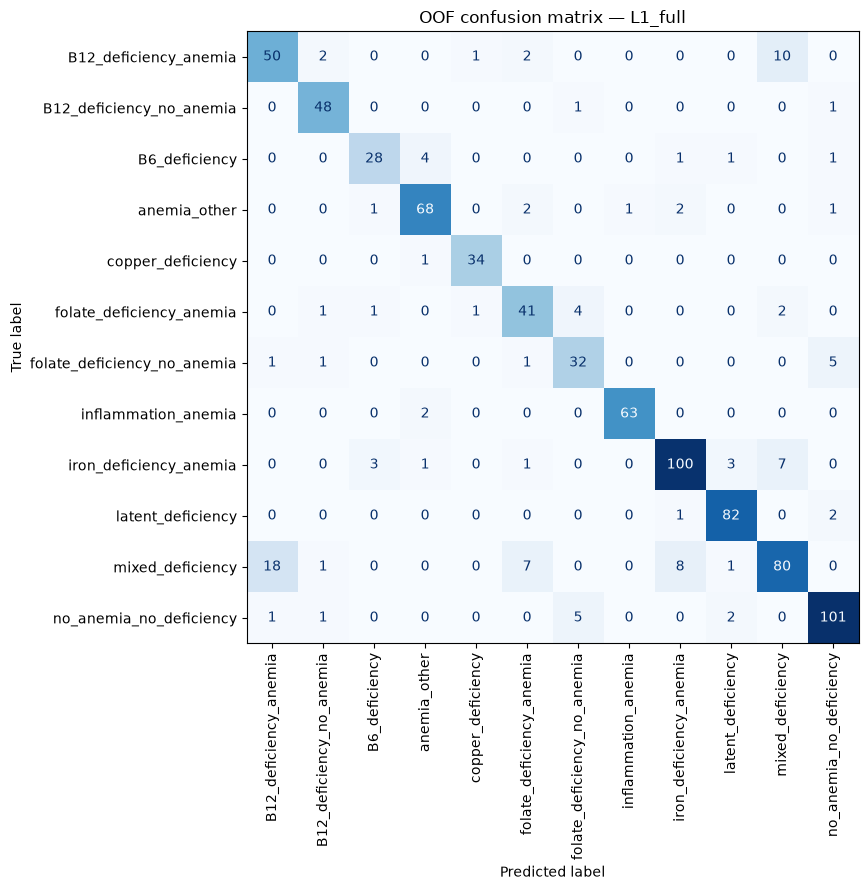

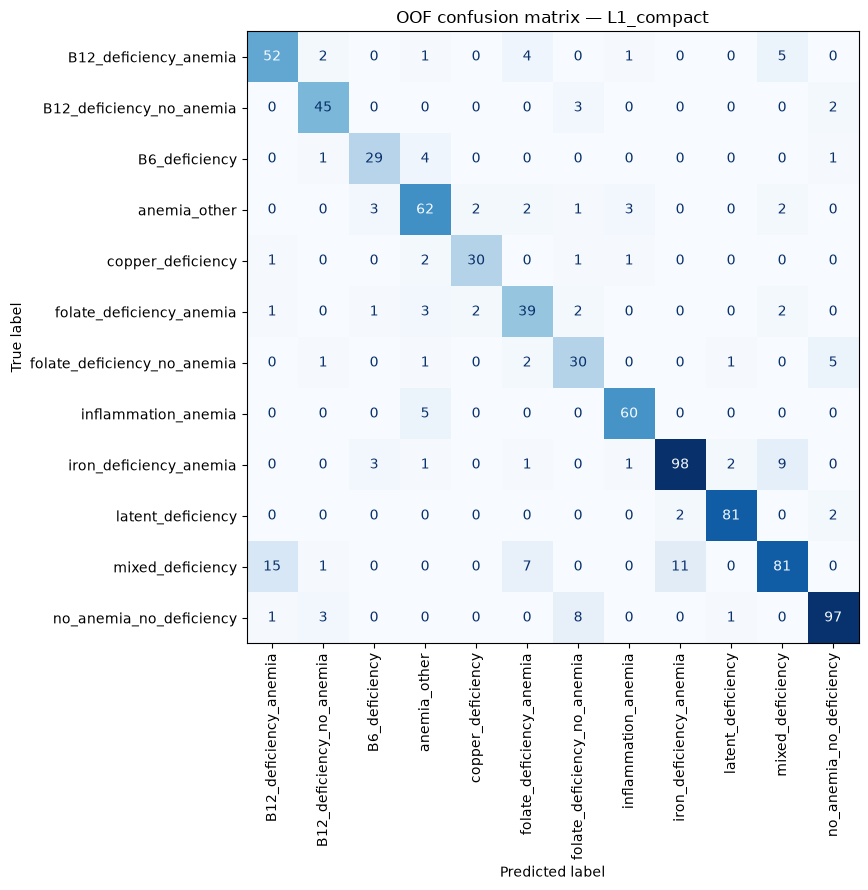

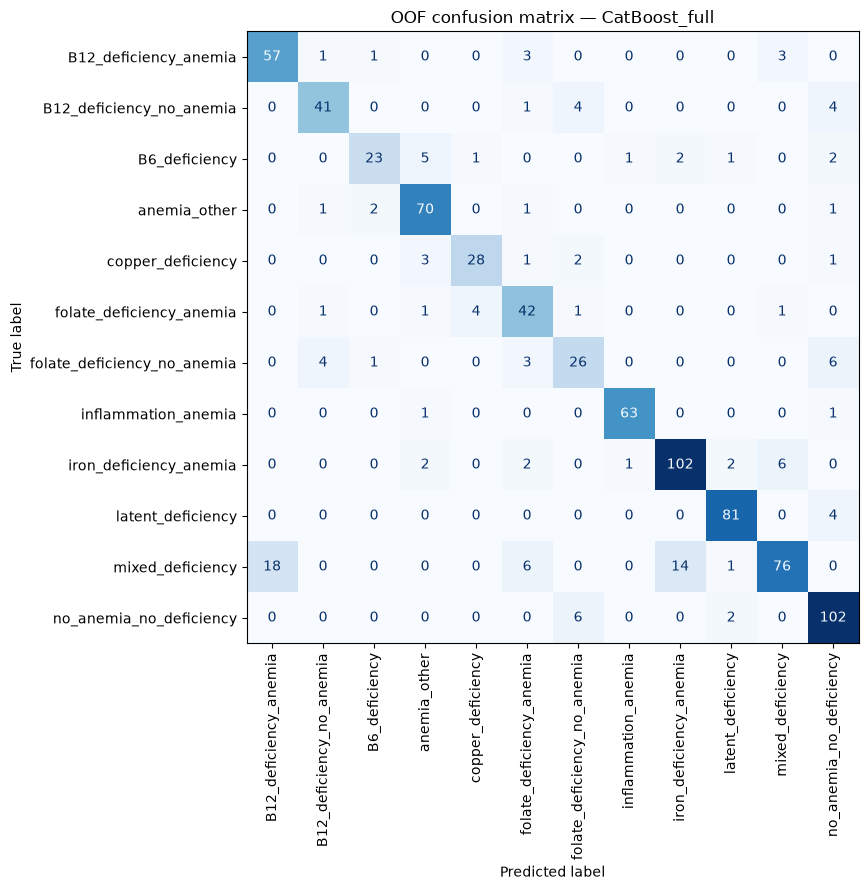

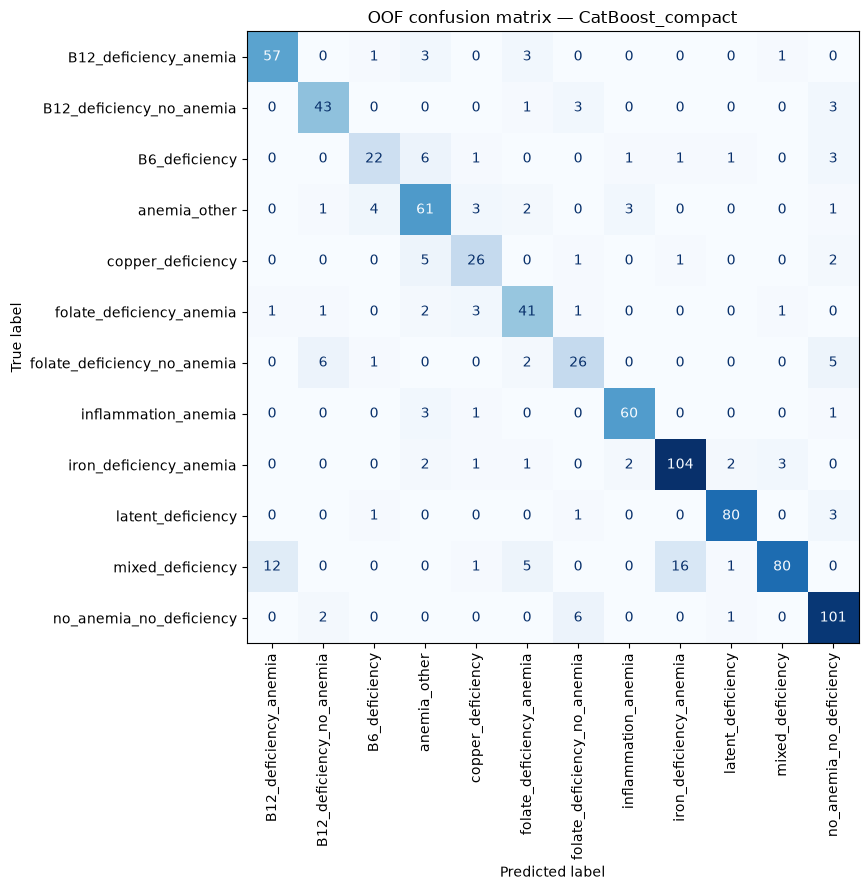

In [15]:

for model_name in MODEL_NAMES:
    fig, ax = plt.subplots(figsize=(11, 9))

    ConfusionMatrixDisplay.from_predictions(
        y,
        oof_predictions[model_name],
        labels=CLASSES,
        xticks_rotation=90,
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )

    ax.set_title(f"OOF confusion matrix — {model_name}")
    plt.tight_layout()
    plt.show()



## 16. Проверяем уверенность вероятностей

Пока **не калибруем** модели — это следующий этап.

Но уже сейчас проверяем:

- насколько средний `max probability` совпадает с реальной долей правильных ответов;
- не является ли модель чрезмерно уверенной.

Это diagnostic calibration table.


In [16]:

def confidence_table(y_true, pred, prob):
    confidence = prob.max(axis=1)
    correct = (np.asarray(pred) == np.asarray(y_true)).astype(int)

    bins = np.linspace(0.0, 1.0, 11)

    table = pd.DataFrame({
        "confidence": confidence,
        "correct": correct,
    })

    table["bin"] = pd.cut(
        table["confidence"],
        bins=bins,
        include_lowest=True,
    )

    result = (
        table
        .groupby("bin", observed=False)
        .agg(
            n=("correct", "size"),
            mean_confidence=("confidence", "mean"),
            empirical_accuracy=("correct", "mean"),
        )
        .reset_index()
    )

    result["gap"] = (
        result["mean_confidence"]
        - result["empirical_accuracy"]
    )

    return result


for model_name in MODEL_NAMES:
    print(f"\n===== {model_name} =====")
    display(
        confidence_table(
            y,
            oof_predictions[model_name],
            oof_probabilities[model_name],
        ).round(3)
    )



===== L1_full =====


,bin,n,mean_confidence,empirical_accuracy,gap
0,"(-0.001, 0.1]",0,NaN,NaN,NaN
1,"(0.1, 0.2]",0,NaN,NaN,NaN
2,"(0.2, 0.3]",7,0.269,0.286,-0.017
3,"(0.3, 0.4]",26,0.359,0.462,-0.102
4,"(0.4, 0.5]",46,0.457,0.565,-0.109
5,"(0.5, 0.6]",82,0.548,0.659,-0.110
6,"(0.6, 0.7]",79,0.654,0.848,-0.194
7,"(0.7, 0.8]",113,0.756,0.885,-0.129
8,"(0.8, 0.9]",134,0.853,0.896,-0.043
9,"(0.9, 1.0]",353,0.970,0.980,-0.010



===== L1_compact =====


,bin,n,mean_confidence,empirical_accuracy,gap
0,"(-0.001, 0.1]",0,NaN,NaN,NaN
1,"(0.1, 0.2]",1,0.160,0.000,0.160
2,"(0.2, 0.3]",10,0.272,0.100,0.172
3,"(0.3, 0.4]",28,0.358,0.250,0.108
4,"(0.4, 0.5]",53,0.458,0.585,-0.127
5,"(0.5, 0.6]",85,0.551,0.682,-0.131
6,"(0.6, 0.7]",78,0.653,0.782,-0.129
7,"(0.7, 0.8]",88,0.753,0.773,-0.020
8,"(0.8, 0.9]",151,0.852,0.921,-0.068
9,"(0.9, 1.0]",346,0.970,0.980,-0.010



===== CatBoost_full =====


,bin,n,mean_confidence,empirical_accuracy,gap
0,"(-0.001, 0.1]",0,NaN,NaN,NaN
1,"(0.1, 0.2]",2,0.182,0.000,0.182
2,"(0.2, 0.3]",22,0.255,0.500,-0.245
3,"(0.3, 0.4]",87,0.357,0.598,-0.241
4,"(0.4, 0.5]",104,0.454,0.721,-0.267
5,"(0.5, 0.6]",95,0.550,0.747,-0.197
6,"(0.6, 0.7]",122,0.653,0.877,-0.224
7,"(0.7, 0.8]",129,0.753,0.938,-0.185
8,"(0.8, 0.9]",157,0.853,0.981,-0.128
9,"(0.9, 1.0]",122,0.940,0.984,-0.044



===== CatBoost_compact =====


,bin,n,mean_confidence,empirical_accuracy,gap
0,"(-0.001, 0.1]",0,NaN,NaN,NaN
1,"(0.1, 0.2]",2,0.186,0.500,-0.314
2,"(0.2, 0.3]",25,0.264,0.440,-0.176
3,"(0.3, 0.4]",75,0.358,0.587,-0.229
4,"(0.4, 0.5]",107,0.452,0.636,-0.183
5,"(0.5, 0.6]",109,0.552,0.761,-0.210
6,"(0.6, 0.7]",110,0.652,0.900,-0.248
7,"(0.7, 0.8]",137,0.750,0.927,-0.177
8,"(0.8, 0.9]",139,0.845,0.978,-0.134
9,"(0.9, 1.0]",136,0.941,0.971,-0.029



## 17. Robustness: пациенты с неполным набором анализов

В EDA мы увидели, что missingness может быть shortcut-признаком.

Здесь оцениваем качество baseline-моделей отдельно у пациентов:

- с относительно полным набором анализов;
- со средним количеством пропусков;
- с большим количеством пропусков.

Группы формируются по тертилям доли отсутствующих входных признаков.


In [17]:

patient_missing_fraction = (
    df[FEATURE_COLUMNS]
    .isna()
    .mean(axis=1)
)

missingness_group = pd.qcut(
    patient_missing_fraction,
    q=3,
    labels=[
        "low_missingness",
        "medium_missingness",
        "high_missingness",
    ],
    duplicates="drop",
)

robustness_rows = []

for model_name in MODEL_NAMES:
    for group_name in pd.Series(missingness_group).dropna().unique():
        mask = (missingness_group == group_name)

        robustness_rows.append({
            "model": model_name,
            "missingness_group": str(group_name),
            "n": int(mask.sum()),
            "mean_missing_fraction": patient_missing_fraction[mask].mean(),
            "macro_f1": f1_score(
                y[mask],
                oof_predictions[model_name][mask],
                average="macro",
                zero_division=0,
            ),
            "accuracy": accuracy_score(
                y[mask],
                oof_predictions[model_name][mask],
            ),
        })

robustness_table = pd.DataFrame(robustness_rows)

display(
    robustness_table
    .sort_values(["model", "mean_missing_fraction"])
    .round(3)
)


,model,missingness_group,n,mean_missing_fraction,macro_f1,accuracy
11,CatBoost_compact,low_missingness,343,0.269,0.837,0.860
9,CatBoost_compact,medium_missingness,236,0.376,0.799,0.847
10,CatBoost_compact,high_missingness,261,0.493,0.720,0.789
8,CatBoost_full,low_missingness,343,0.269,0.867,0.860
6,CatBoost_full,medium_missingness,236,0.376,0.803,0.852
7,CatBoost_full,high_missingness,261,0.493,0.786,0.824
5,L1_compact,low_missingness,343,0.269,0.837,0.840
3,L1_compact,medium_missingness,236,0.376,0.837,0.864
4,L1_compact,high_missingness,261,0.493,0.740,0.812
2,L1_full,low_missingness,343,0.269,0.840,0.851



## 18. Сохраняем результаты

Сохраняем только результаты baseline-эксперимента:

- OOF predictions;
- OOF probabilities;
- fold metrics;
- summary;
- стабильность compact feature selection;
- consensus feature set.

Это пригодится в следующем ноутбуке для иерархической модели и ансамбля.


In [18]:

ARTIFACT_DIR = Path("../artifacts/baselines")
if not ARTIFACT_DIR.parent.exists():
    ARTIFACT_DIR = Path("artifacts/baselines")

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

oof_export = pd.DataFrame({
    "patient_id": df[ID_COLUMN],
    "y_true": y,
})

for model_name in MODEL_NAMES:
    oof_export[f"{model_name}__pred"] = oof_predictions[model_name]

    for class_idx, class_name in enumerate(CLASSES):
        safe_class_name = str(class_name).replace(" ", "_")
        oof_export[
            f"{model_name}__proba__{safe_class_name}"
        ] = oof_probabilities[model_name][:, class_idx]

oof_export.to_csv(
    ARTIFACT_DIR / "oof_predictions.csv",
    index=False,
)

fold_metrics_df.to_csv(
    ARTIFACT_DIR / "fold_metrics.csv",
    index=False,
)

oof_summary.to_csv(
    ARTIFACT_DIR / "oof_summary.csv",
)

compact_stability.to_csv(
    ARTIFACT_DIR / "compact_feature_stability.csv",
    index=False,
)

pd.Series(
    consensus_compact_features,
    name="feature",
).to_csv(
    ARTIFACT_DIR / "consensus_compact_features.csv",
    index=False,
)

print("Результаты сохранены в:", ARTIFACT_DIR.resolve())


Результаты сохранены в: /home/sinopah/meditron/notebooks/artifacts/baselines



# 19. Как интерпретировать результат

После выполнения ноутбука отвечаем на четыре вопроса.

### 1. Помогает ли уменьшение размерности?

Сравниваем:

```text
L1_full        vs L1_compact
CatBoost_full  vs CatBoost_compact
```

Если compact-модель сохраняет или улучшает `Macro-F1`, при этом использует существенно меньше признаков — это аргумент в пользу компактной панели.

Если compact сильно проигрывает — не сокращаем пространство признаков только ради красивой архитектуры.

### 2. Стала ли L1 действительно sparse?

В таблице `l1_stability` должны появиться признаки, которые не выбираются во всех folds.

Если снова практически всё имеет ненулевой коэффициент, можно расширить `C_GRID` ещё ниже:

```python
np.logspace(-5, 0, ...)
```

но решение принимается по inner CV, а не вручную по outer validation.

### 3. Насколько стабильны результаты?

Смотрим одновременно:

- среднее Macro-F1;
- std Macro-F1 между folds;
- per-class recall/F1;
- confusion matrix.

Особенно важны редкие классы `B6_deficiency`, `copper_deficiency` и смешанные состояния.

### 4. Что происходит при неполных анализах?

Если качество резко растёт/падает вместе с количеством пропусков, это отдельный риск.

В следующем этапе мы дополнительно будем проверять, не использует ли модель паттерн назначения анализов как shortcut.

---

# 20. Следующий этап проекта

После этого ноутбука:

1. выбираем baseline-архитектуру;
2. фиксируем consensus compact feature set;
3. переходим к иерархической постановке:
   - `anemia` — детерминированное правило Hb + пол;
   - отдельные модели/вероятности для дефицитов;
   - сборка `anemia_class` и `deficiency_cause`;
4. добавляем rule-based слой с подтверждёнными клиническими порогами;
5. калибруем OOF probabilities;
6. строим weighted ensemble:
   - L1;
   - CatBoost;
   - clinical rules;
7. после этого отдельно тестируем расширение датасета и внешний источник.

**Главный принцип остаётся тем же:**

> сначала честная validation, потом усложнение модели.
